In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [8]:
df = pd.read_csv("loan_data_total.csv", sep=";")
print(f"quantidade de dados: {len(df)}")
print(df.head(10))

quantidade de dados: 2033575
        id data_celebracao data_primeiro_emprestimo data_ultimo_pagamento  \
0  1077501      2011-12-01               1985-01-01            2015-01-01   
1  1077175      2011-12-01               2001-11-01            2014-06-01   
2  1076863      2011-12-01               1996-02-01            2015-01-01   
3  1075269      2011-12-01               2004-11-01            2015-01-01   
4  1072053      2011-12-01               2007-01-01            2015-01-01   
5  1069908      2011-12-01               1989-10-01            2013-09-01   
6  1064687      2011-12-01               2004-04-01            2012-07-01   
7  1069866      2011-12-01               2003-07-01            2015-01-01   
8  1069057      2011-12-01               1991-05-01            2013-10-01   
9  1069759      2011-12-01               2007-09-01            2015-01-01   

   valor_financiado finalidade_emprestimo  parcelas  taxa_juros  \
0            5000.0     cartao de credito        36     

In [12]:
n_amostra = int(len(df) * 0.1)  # 10% da base original

# Amostragem estratificada
df_amostra, _ = train_test_split(
    df,
    train_size=n_amostra,
    stratify=df["default"],
    random_state=42
)

# Conferindo o tamanho da amostra
print("Tamanho da base original:", df.shape)
print("Tamanho da amostra:", df_amostra.shape)

# Conferindo proporção das classes na base original
print("\nProporção na base original:")
print(df["default"].value_counts(normalize=True))

# Conferindo proporção das classes na amostra
print("\nProporção na amostra:")
print(df_amostra["default"].value_counts(normalize=True))

Tamanho da base original: (2033575, 17)
Tamanho da amostra: (203357, 17)

Proporção na base original:
default
0    0.894148
1    0.105852
Name: proportion, dtype: float64

Proporção na amostra:
default
0    0.894147
1    0.105853
Name: proportion, dtype: float64


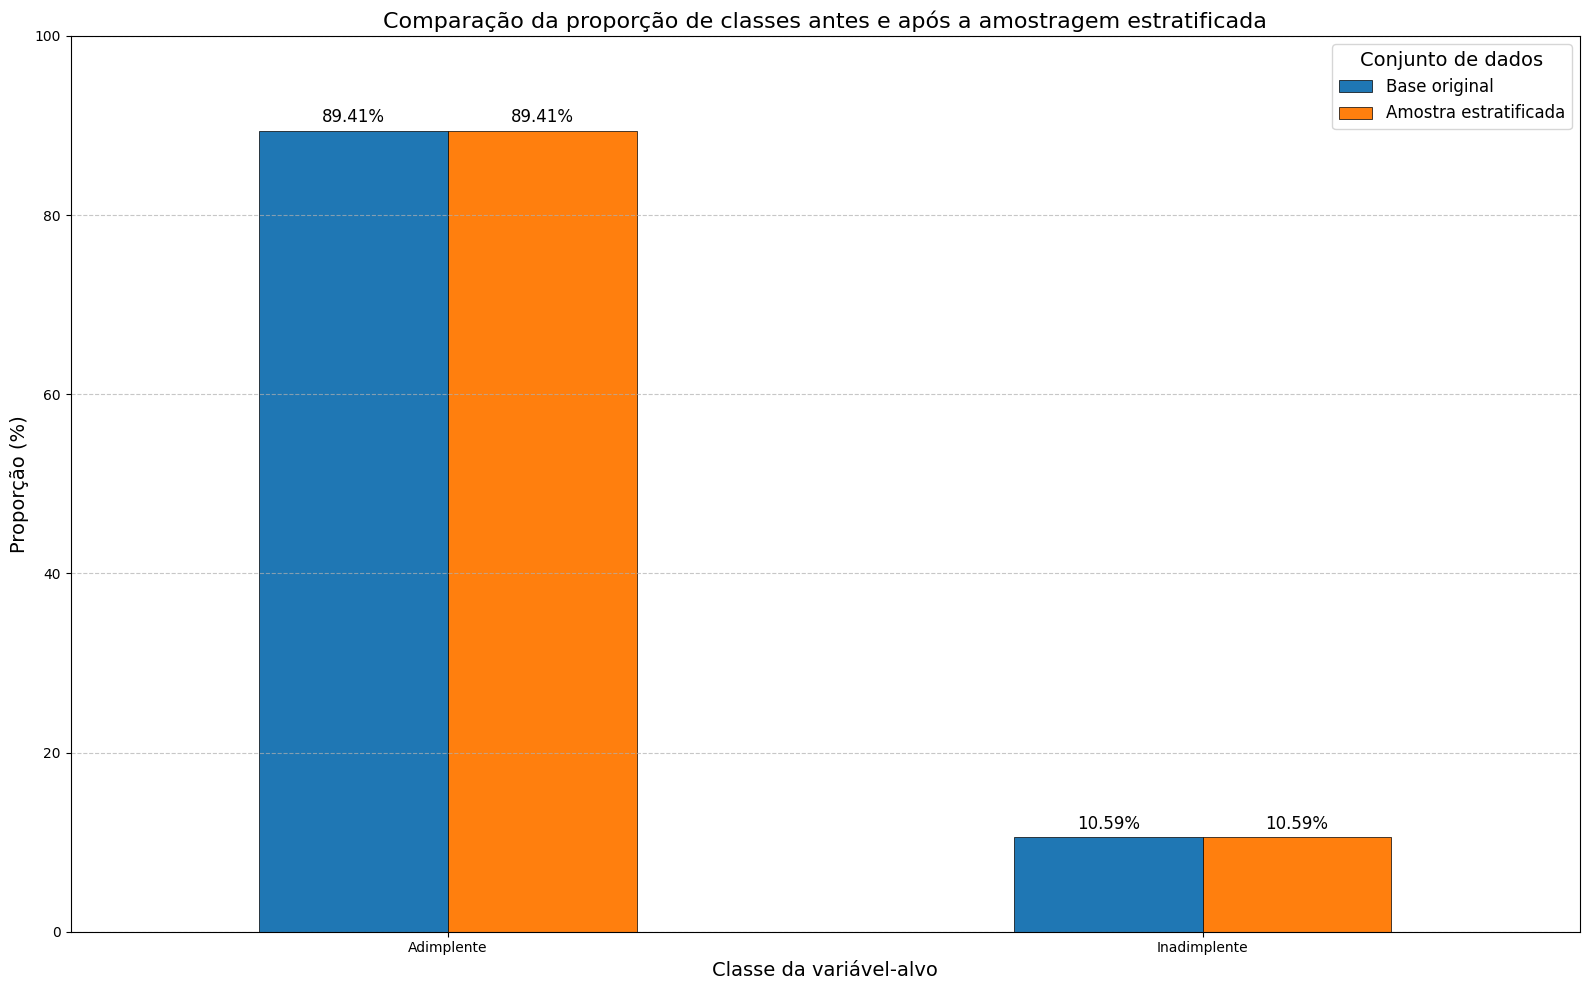

In [19]:
# Calculando proporções
prop_original = df["default"].value_counts(normalize=True).sort_index()
prop_amostra = df_amostra["default"].value_counts(normalize=True).sort_index()

# Organizando em DataFrame para plot
df_prop = pd.DataFrame({"Base original": prop_original, "Amostra estratificada": prop_amostra})

# Convertendo para percentual
df_prop = df_prop * 100

# Renomeando classes, se desejar
df_prop.index = ["Adimplente", "Inadimplente"]

# Gráfico de barras comparativo
ax = df_prop.plot(
    kind="bar",
    figsize=(16, 10),
    rot=0,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Comparação da proporção de classes antes e após a amostragem estratificada", fontsize=16)
plt.ylabel("Proporção (%)", fontsize=14)
plt.xlabel("Classe da variável-alvo", fontsize=14)
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Conjunto de dados", fontsize=12, title_fontsize=14)

# Inserindo valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=12)

plt.tight_layout()
plt.savefig("./figuras/comparacao_proporcao_classes.png", dpi=300)
plt.show()

In [21]:
display(df_amostra.head())
df_amostra.to_csv("amostra_estratificada.csv", index=False, sep=";")

,id,data_celebracao,data_primeiro_emprestimo,data_ultimo_pagamento,valor_financiado,finalidade_emprestimo,parcelas,taxa_juros,valor_parcela,tempo_relacionamento,escore_fico,inadimplencia_2_anos,registros_publicos_negativos,renda_mensal,compm_renda,default,T
1908525,98064561,2017-03-01,2003-03-01,2020-03-01,8000.0,compra de veiculo,36,0.0824,251.58,168,672,0,1,7416.67,0.0339,0,36
1739451,90070467,2016-09-01,2007-01-01,2017-05-01,3200.0,pagamento de dividas,36,0.1279,107.50,116,662,1,0,3375.00,0.0319,1,8
925891,154971114,2019-07-01,2003-09-01,2019-10-01,10000.0,cartao de credito,36,0.0702,308.87,190,682,0,0,5331.17,0.0579,0,3
802350,151063749,2019-05-01,1995-09-01,2020-05-01,12625.0,pagamento de dividas,36,0.0702,389.94,284,737,1,0,4333.33,0.0900,0,12
861013,157836904,2019-09-01,2007-11-01,2020-05-01,5000.0,pagamento de dividas,36,0.1308,168.67,142,707,0,0,3333.33,0.0506,0,8
